# Neural Network Hyperparameter Tuning

**Objective**: Systematic hyperparameter tuning for Neural Network classifier across multiple tasks.

## Hyperparameter Grid:
1. **hidden_layers**: Network architecture `[(256,), (512,), (256, 128), (512, 256)]`
2. **dropout_rate**: Dropout probability `[0.2, 0.3, 0.4, 0.5]`
3. **learning_rate**: Adam optimizer learning rate `[0.0001, 0.001, 0.01, 0.1]`
4. **batch_size**: Training batch size `[16, 32, 64, 128]`

## Tasks:
- Country Classification (16 classes)
- Time of Day Classification (4 classes)
- Activity Classification (4 classes)

## Output:
Results saved to `results/hyperparameter_tuning/neural_network/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Try to import PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print("✓ PyTorch available")
except ImportError:
    TORCH_AVAILABLE = False
    print("✗ PyTorch not available - please install PyTorch to run this notebook")
    raise ImportError("PyTorch is required for this notebook")

# Setup paths
START_DIR = Path.cwd()
PROJECT_ROOT = START_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_DIR = DATA_DIR / 'features'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'hyperparameter_tuning' / 'neural_network'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Setup complete.")
print(f"Results will be saved to: {RESULTS_DIR}")

✓ PyTorch available
Using device: cuda
Setup complete.
Results will be saved to: c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\neural_network


## 1. Load Cleaned Data & Prepare Labels

In [2]:
# 1. Load Metadata
cleaned_df = pd.read_csv(DATA_DIR / 'processed' / 'cleaned_dataset.csv')

# 2. Derive Activity
def derive_activity(text):
    text = str(text).lower()
    keywords = {
        'Nature': ['park', 'garden', 'mountain', 'lake', 'river', 'nature', 'hike', 'hiking', 'forest', 'valley', 'waterfall', 'beach', 'sea', 'ocean', 'island', 'sand', 'cave', 'rock', 'hill', 'view', 'landscape', 'sunrise', 'sunset'],
        'History': ['museum', 'castle', 'palace', 'temple', 'church', 'cathedral', 'history', 'ancient', 'monument', 'ruins', 'art', 'statue', 'shrine', 'mosque', 'tomb', 'archaeology', 'historic'],
        'Urban': ['city', 'street', 'building', 'bridge', 'tower', 'square', 'market', 'shop', 'downtown', 'urban', 'skyline', 'hotel', 'mall', 'road', 'town', 'architecture', 'skyscraper'],
    }
    for cat in ['History', 'Urban', 'Nature']:
        if any(w in text for w in keywords[cat]):
            return cat
    return 'Leisure/Other'

cleaned_df['Activity'] = cleaned_df['Description'].apply(derive_activity)

# 3. Filter Valid Data
CONFIG = {
    'top_n_countries': 15,
    'valid_times': ['Morning', 'Afternoon', 'Evening', 'Night'],
    'test_size': 0.20,
    'random_state': 42
}

valid_mask = cleaned_df['Time_of_Day_Standardized'].isin(CONFIG['valid_times'])
df = cleaned_df[valid_mask].copy().reset_index(drop=True)
valid_indices = np.where(valid_mask)[0]

print(f"Valid samples: {len(df)}")

# 4. Encoders
country_counts_all = df['Country_Standardized'].value_counts()
top_countries = set(country_counts_all.head(CONFIG['top_n_countries']).index)
df['Country_Grouped'] = df['Country_Standardized'].apply(lambda x: x if x in top_countries else 'Other')

country_encoder = LabelEncoder()
country_encoder.fit(sorted(list(top_countries) + ['Other']))
time_encoder = LabelEncoder()
time_encoder.fit(CONFIG['valid_times'])
activity_encoder = LabelEncoder()
activity_encoder.fit(sorted(df['Activity'].unique()))

y_country = country_encoder.transform(df['Country_Grouped'].values)
y_time = time_encoder.transform(df['Time_of_Day_Standardized'].values)
y_activity = activity_encoder.transform(df['Activity'].values)

# 5. Stratified Split
strat_key = (df['Country_Grouped'] + '_' + df['Time_of_Day_Standardized'] + '_' + df['Activity'])
strat_counts = strat_key.value_counts()
strat_key_safe = strat_key.apply(lambda x: 'OTHER' if strat_counts[x] < 2 else x)

train_idx_global, test_idx_global = train_test_split(
    list(range(len(df))), 
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=strat_key_safe.values
)

print(f"Split prepared: {len(train_idx_global)} Train, {len(test_idx_global)} Test")

Valid samples: 945
Split prepared: 756 Train, 189 Test


## 2. Load Features & Evaluation Function

In [3]:
def evaluate_model(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

# Load normalized features
features_all = np.load(FEATURES_DIR / 'places_features_pretrained_normalized.npy')

# Filter valid indices
X_valid = features_all[valid_indices]

# Split
X_train = X_valid[train_idx_global]
X_test = X_valid[test_idx_global]

# Get targets
y_train_c, y_test_c = y_country[train_idx_global], y_country[test_idx_global]
y_train_t, y_test_t = y_time[train_idx_global], y_time[test_idx_global]
y_train_a, y_test_a = y_activity[train_idx_global], y_activity[test_idx_global]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"Number of classes: Country={len(country_encoder.classes_)}, Time={len(time_encoder.classes_)}, Activity={len(activity_encoder.classes_)}")

X_train shape: (756, 2432)
X_test shape: (189, 2432)
Number of classes: Country=16, Time=4, Activity=4


## 3. Define Neural Network Architecture

In [4]:
class FlexibleMLP(nn.Module):
    """Flexible Multi-Layer Perceptron with configurable architecture"""
    def __init__(self, in_dim, out_dim, hidden_layers=(512,), dropout_rate=0.4):
        super().__init__()
        
        layers = []
        prev_dim = in_dim
        
        # Build hidden layers
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, out_dim))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

def train_nn_task(y_train_target, y_test_target, n_classes, 
                  hidden_layers=(512,), dropout_rate=0.4, 
                  learning_rate=0.001, batch_size=32, epochs=30):
    """Train a neural network for a specific task"""
    
    # Create data loaders
    X_t = torch.FloatTensor(X_train_scaled).to(device)
    y_t = torch.LongTensor(y_train_target).to(device)
    train_dataset = TensorDataset(X_t, y_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    model = FlexibleMLP(
        in_dim=X_train_scaled.shape[1],
        out_dim=n_classes,
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate
    ).to(device)
    
    # Setup optimizer and loss
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
        predictions = model(X_test_tensor).argmax(dim=1).cpu().numpy()
    
    return predictions

print("Neural network functions defined.")

Neural network functions defined.


## 4. Neural Network Hyperparameter Tuning

In [5]:
# Hyperparameter grid
hidden_layers_list = [(256,), (512,), (256, 128), (512, 256)]
dropout_rates = [0.2, 0.3, 0.4, 0.5]
learning_rates = [0.0001, 0.001, 0.01, 0.1]
batch_sizes = [16, 32, 64, 128]

results_list = []

# First sweep: hidden_layers and dropout_rate
total_configs = len(hidden_layers_list) * len(dropout_rates)
print(f"Starting hyperparameter tuning - Phase 1: Architecture & Dropout")
print(f"Testing {total_configs} configurations (hidden_layers × dropout_rate)")
print("Using fixed learning_rate=0.001, batch_size=32")
print("="*80)

config_num = 0
for hidden_layers in hidden_layers_list:
    for dropout_rate in dropout_rates:
        config_num += 1
        
        try:
            # Train models for each task
            pred_c = train_nn_task(
                y_train_c, y_test_c, len(country_encoder.classes_),
                hidden_layers=hidden_layers, dropout_rate=dropout_rate,
                learning_rate=0.001, batch_size=32, epochs=30
            )
            pred_t = train_nn_task(
                y_train_t, y_test_t, len(time_encoder.classes_),
                hidden_layers=hidden_layers, dropout_rate=dropout_rate,
                learning_rate=0.001, batch_size=32, epochs=30
            )
            pred_a = train_nn_task(
                y_train_a, y_test_a, len(activity_encoder.classes_),
                hidden_layers=hidden_layers, dropout_rate=dropout_rate,
                learning_rate=0.001, batch_size=32, epochs=30
            )
            
            # Evaluate
            res_c = evaluate_model(y_test_c, pred_c)
            res_t = evaluate_model(y_test_t, pred_t)
            res_a = evaluate_model(y_test_a, pred_a)
            
            # Store results
            result = {
                'hidden_layers': str(hidden_layers),
                'dropout_rate': dropout_rate,
                'learning_rate': 0.001,
                'batch_size': 32,
                'country_accuracy': res_c['accuracy'],
                'country_f1_macro': res_c['f1_macro'],
                'country_f1_weighted': res_c['f1_weighted'],
                'time_accuracy': res_t['accuracy'],
                'time_f1_macro': res_t['f1_macro'],
                'time_f1_weighted': res_t['f1_weighted'],
                'activity_accuracy': res_a['accuracy'],
                'activity_f1_macro': res_a['f1_macro'],
                'activity_f1_weighted': res_a['f1_weighted'],
                'avg_accuracy': (res_c['accuracy'] + res_t['accuracy'] + res_a['accuracy']) / 3
            }
            results_list.append(result)
            
            print(f"[{config_num}/{total_configs}] hidden_layers={hidden_layers}, dropout={dropout_rate:.1f} -> "
                  f"Country: {res_c['accuracy']:.4f}, Time: {res_t['accuracy']:.4f}, "
                  f"Activity: {res_a['accuracy']:.4f}, Avg: {result['avg_accuracy']:.4f}")
        
        except Exception as e:
            print(f"[{config_num}/{total_configs}] Error with config hidden_layers={hidden_layers}, dropout={dropout_rate}: {str(e)}")
            continue

print("\n" + "="*80)
print("Phase 2: Learning Rate & Batch Size")
print("Using best architecture and dropout from Phase 1")
print("="*80)

# Find best architecture from phase 1
temp_df = pd.DataFrame(results_list)
best_config = temp_df.loc[temp_df['avg_accuracy'].idxmax()]
best_hidden_layers_str = best_config['hidden_layers']
best_hidden_layers = eval(best_hidden_layers_str)
best_dropout = float(best_config['dropout_rate'])

print(f"Best from Phase 1: hidden_layers={best_hidden_layers}, dropout={best_dropout}")

total_configs2 = len(learning_rates) * len(batch_sizes)
config_num = 0

for lr in learning_rates:
    for batch_size in batch_sizes:
        # Skip default combination (already tested)
        if lr == 0.001 and batch_size == 32:
            continue
        
        config_num += 1
        
        try:
            # Train models for each task
            pred_c = train_nn_task(
                y_train_c, y_test_c, len(country_encoder.classes_),
                hidden_layers=best_hidden_layers, dropout_rate=best_dropout,
                learning_rate=lr, batch_size=batch_size, epochs=30
            )
            pred_t = train_nn_task(
                y_train_t, y_test_t, len(time_encoder.classes_),
                hidden_layers=best_hidden_layers, dropout_rate=best_dropout,
                learning_rate=lr, batch_size=batch_size, epochs=30
            )
            pred_a = train_nn_task(
                y_train_a, y_test_a, len(activity_encoder.classes_),
                hidden_layers=best_hidden_layers, dropout_rate=best_dropout,
                learning_rate=lr, batch_size=batch_size, epochs=30
            )
            
            # Evaluate
            res_c = evaluate_model(y_test_c, pred_c)
            res_t = evaluate_model(y_test_t, pred_t)
            res_a = evaluate_model(y_test_a, pred_a)
            
            # Store results
            result = {
                'hidden_layers': str(best_hidden_layers),
                'dropout_rate': best_dropout,
                'learning_rate': lr,
                'batch_size': batch_size,
                'country_accuracy': res_c['accuracy'],
                'country_f1_macro': res_c['f1_macro'],
                'country_f1_weighted': res_c['f1_weighted'],
                'time_accuracy': res_t['accuracy'],
                'time_f1_macro': res_t['f1_macro'],
                'time_f1_weighted': res_t['f1_weighted'],
                'activity_accuracy': res_a['accuracy'],
                'activity_f1_macro': res_a['f1_macro'],
                'activity_f1_weighted': res_a['f1_weighted'],
                'avg_accuracy': (res_c['accuracy'] + res_t['accuracy'] + res_a['accuracy']) / 3
            }
            results_list.append(result)
            
            print(f"[{config_num}/{total_configs2-1}] lr={lr}, batch_size={batch_size} -> "
                  f"Country: {res_c['accuracy']:.4f}, Time: {res_t['accuracy']:.4f}, "
                  f"Activity: {res_a['accuracy']:.4f}, Avg: {result['avg_accuracy']:.4f}")
        
        except Exception as e:
            print(f"[{config_num}/{total_configs2-1}] Error with config lr={lr}, batch_size={batch_size}: {str(e)}")
            continue

results_df = pd.DataFrame(results_list)
print("\n" + "="*80)
print("Hyperparameter tuning complete!")
print("="*80)

Starting hyperparameter tuning - Phase 1: Architecture & Dropout
Testing 16 configurations (hidden_layers × dropout_rate)
Using fixed learning_rate=0.001, batch_size=32
[1/16] hidden_layers=(256,), dropout=0.2 -> Country: 0.7778, Time: 0.5450, Activity: 0.7196, Avg: 0.6808
[2/16] hidden_layers=(256,), dropout=0.3 -> Country: 0.7725, Time: 0.5714, Activity: 0.7090, Avg: 0.6843
[3/16] hidden_layers=(256,), dropout=0.4 -> Country: 0.7566, Time: 0.5714, Activity: 0.7090, Avg: 0.6790
[4/16] hidden_layers=(256,), dropout=0.5 -> Country: 0.7619, Time: 0.5344, Activity: 0.6931, Avg: 0.6631
[5/16] hidden_layers=(512,), dropout=0.2 -> Country: 0.7460, Time: 0.5873, Activity: 0.7143, Avg: 0.6825
[6/16] hidden_layers=(512,), dropout=0.3 -> Country: 0.7725, Time: 0.5608, Activity: 0.7302, Avg: 0.6878
[7/16] hidden_layers=(512,), dropout=0.4 -> Country: 0.7354, Time: 0.5661, Activity: 0.7037, Avg: 0.6684
[8/16] hidden_layers=(512,), dropout=0.5 -> Country: 0.7302, Time: 0.5661, Activity: 0.6984, Avg

## 5. Analyze Results

In [6]:
# Save Results CSV
csv_path = RESULTS_DIR / 'nn_hyperparameter_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"✓ Saved results to {csv_path}")

# Save JSON Results
json_results = results_df.to_dict('records')
json_path = RESULTS_DIR / 'nn_hyperparameter_results.json'
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"✓ Saved JSON to {json_path}")

# Find best configurations
print("\n" + "="*80)
print("BEST CONFIGURATIONS")
print("="*80)

best_country = results_df.loc[results_df['country_accuracy'].idxmax()]
print(f"\nBest for Country Classification:")
print(f"  hidden_layers={best_country['hidden_layers']}, dropout={best_country['dropout_rate']}, "
      f"lr={best_country['learning_rate']}, batch_size={best_country['batch_size']}")
print(f"  Accuracy: {best_country['country_accuracy']:.4f}, F1-Macro: {best_country['country_f1_macro']:.4f}")

best_time = results_df.loc[results_df['time_accuracy'].idxmax()]
print(f"\nBest for Time Classification:")
print(f"  hidden_layers={best_time['hidden_layers']}, dropout={best_time['dropout_rate']}, "
      f"lr={best_time['learning_rate']}, batch_size={best_time['batch_size']}")
print(f"  Accuracy: {best_time['time_accuracy']:.4f}, F1-Macro: {best_time['time_f1_macro']:.4f}")

best_activity = results_df.loc[results_df['activity_accuracy'].idxmax()]
print(f"\nBest for Activity Classification:")
print(f"  hidden_layers={best_activity['hidden_layers']}, dropout={best_activity['dropout_rate']}, "
      f"lr={best_activity['learning_rate']}, batch_size={best_activity['batch_size']}")
print(f"  Accuracy: {best_activity['activity_accuracy']:.4f}, F1-Macro: {best_activity['activity_f1_macro']:.4f}")

best_overall = results_df.loc[results_df['avg_accuracy'].idxmax()]
print(f"\nBest Overall (Average Accuracy):")
print(f"  hidden_layers={best_overall['hidden_layers']}, dropout={best_overall['dropout_rate']}, "
      f"lr={best_overall['learning_rate']}, batch_size={best_overall['batch_size']}")
print(f"  Average Accuracy: {best_overall['avg_accuracy']:.4f}")

✓ Saved results to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\neural_network\nn_hyperparameter_results.csv
✓ Saved JSON to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\neural_network\nn_hyperparameter_results.json

BEST CONFIGURATIONS

Best for Country Classification:
  hidden_layers=(512,), dropout=0.3, lr=0.0001, batch_size=16
  Accuracy: 0.7884, F1-Macro: 0.7786

Best for Time Classification:
  hidden_layers=(512,), dropout=0.3, lr=0.01, batch_size=32
  Accuracy: 0.5979, F1-Macro: 0.4381

Best for Activity Classification:
  hidden_layers=(512,), dropout=0.3, lr=0.0001, batch_size=64
  Accuracy: 0.7354, F1-Macro: 0.6858

Best Overall (Average Accuracy):
  hidden_layers=(512,), dropout=0.3, lr=0.01, batch_size=32
  Average Accuracy: 0.6949


## 6. Visualizations

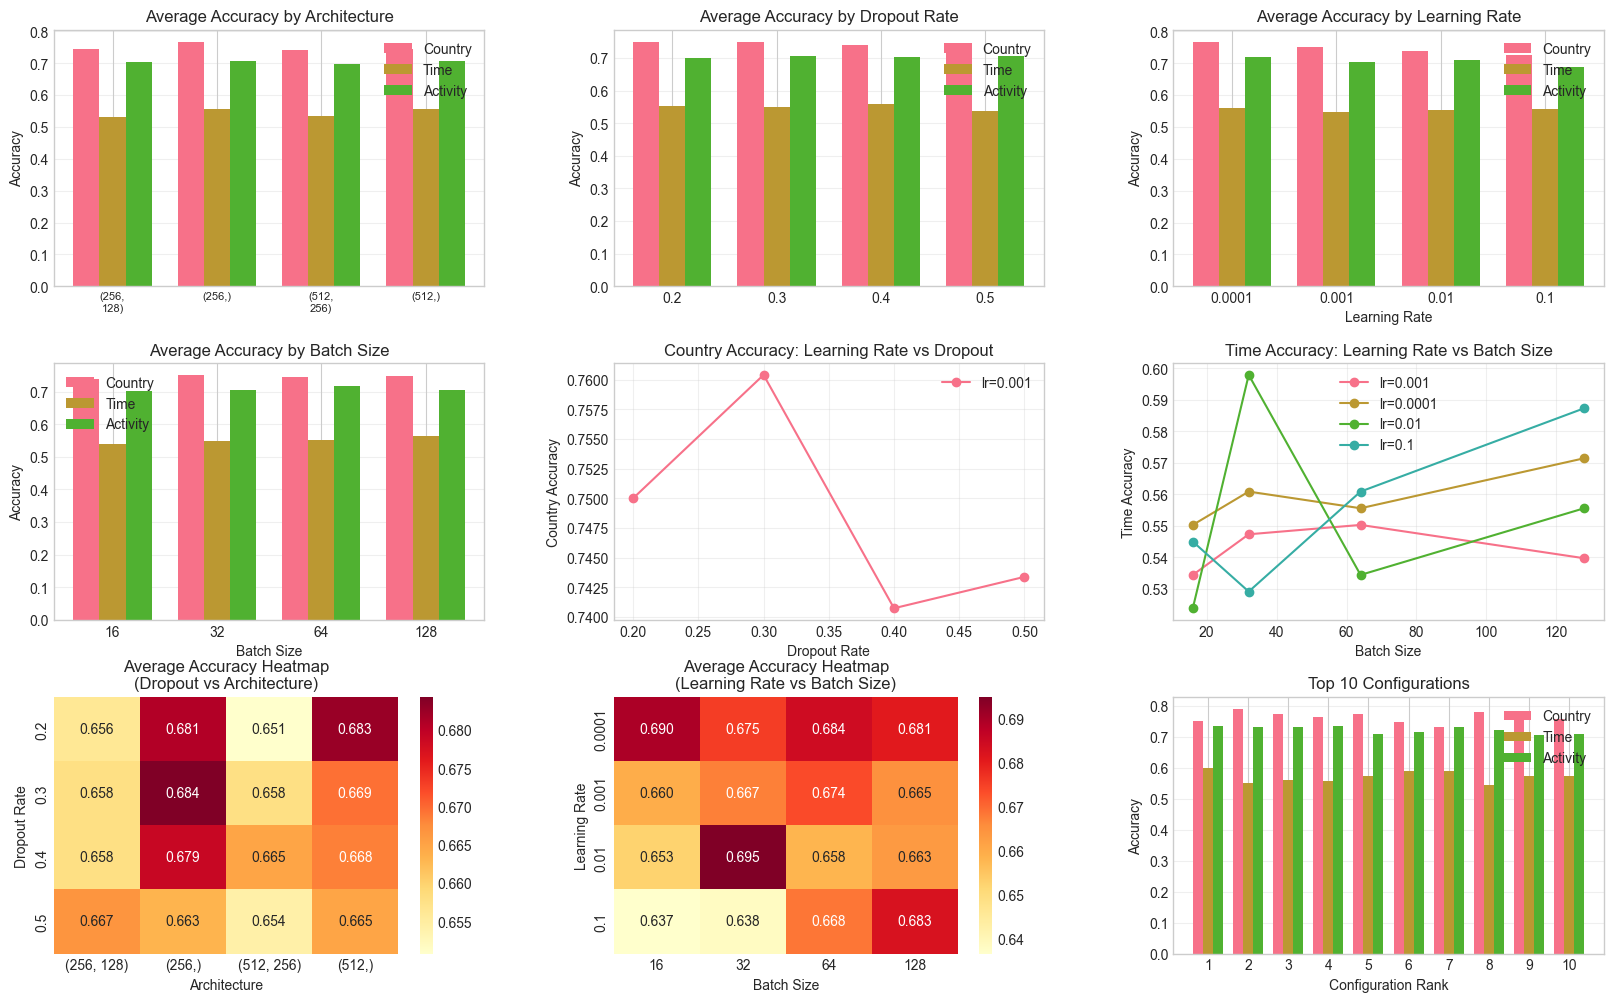

✓ Saved visualization to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\neural_network\nn_hyperparameter_comparison.png


In [7]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Hidden layers comparison
ax1 = fig.add_subplot(gs[0, 0])
hidden_avg = results_df.groupby('hidden_layers')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(hidden_avg.index))
width = 0.25
ax1.bar(x_pos - width, hidden_avg['country_accuracy'], width, label='Country')
ax1.bar(x_pos, hidden_avg['time_accuracy'], width, label='Time')
ax1.bar(x_pos + width, hidden_avg['activity_accuracy'], width, label='Activity')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([h.replace(', ', ',\n') for h in hidden_avg.index], fontsize=8)
ax1.set_ylabel('Accuracy')
ax1.set_title('Average Accuracy by Architecture')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Dropout rate comparison
ax2 = fig.add_subplot(gs[0, 1])
dropout_avg = results_df.groupby('dropout_rate')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(dropout_avg.index))
ax2.bar(x_pos - width, dropout_avg['country_accuracy'], width, label='Country')
ax2.bar(x_pos, dropout_avg['time_accuracy'], width, label='Time')
ax2.bar(x_pos + width, dropout_avg['activity_accuracy'], width, label='Activity')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(dropout_avg.index)
ax2.set_ylabel('Accuracy')
ax2.set_title('Average Accuracy by Dropout Rate')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Learning rate comparison
ax3 = fig.add_subplot(gs[0, 2])
lr_avg = results_df.groupby('learning_rate')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(lr_avg.index))
ax3.bar(x_pos - width, lr_avg['country_accuracy'], width, label='Country')
ax3.bar(x_pos, lr_avg['time_accuracy'], width, label='Time')
ax3.bar(x_pos + width, lr_avg['activity_accuracy'], width, label='Activity')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(lr_avg.index)
ax3.set_ylabel('Accuracy')
ax3.set_xlabel('Learning Rate')
ax3.set_title('Average Accuracy by Learning Rate')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Batch size comparison
ax4 = fig.add_subplot(gs[1, 0])
batch_avg = results_df.groupby('batch_size')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(batch_avg.index))
ax4.bar(x_pos - width, batch_avg['country_accuracy'], width, label='Country')
ax4.bar(x_pos, batch_avg['time_accuracy'], width, label='Time')
ax4.bar(x_pos + width, batch_avg['activity_accuracy'], width, label='Activity')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(batch_avg.index)
ax4.set_ylabel('Accuracy')
ax4.set_xlabel('Batch Size')
ax4.set_title('Average Accuracy by Batch Size')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Learning rate vs Dropout (Country accuracy)
ax5 = fig.add_subplot(gs[1, 1])
for lr in results_df['learning_rate'].unique():
    subset = results_df[results_df['learning_rate'] == lr]
    grouped = subset.groupby('dropout_rate')['country_accuracy'].mean()
    if len(grouped) > 1:
        ax5.plot(grouped.index, grouped.values, marker='o', label=f'lr={lr}')
ax5.set_xlabel('Dropout Rate')
ax5.set_ylabel('Country Accuracy')
ax5.set_title('Country Accuracy: Learning Rate vs Dropout')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Learning rate vs Batch size (Time accuracy)
ax6 = fig.add_subplot(gs[1, 2])
for lr in results_df['learning_rate'].unique():
    subset = results_df[results_df['learning_rate'] == lr]
    grouped = subset.groupby('batch_size')['time_accuracy'].mean()
    if len(grouped) > 1:
        ax6.plot(grouped.index, grouped.values, marker='o', label=f'lr={lr}')
ax6.set_xlabel('Batch Size')
ax6.set_ylabel('Time Accuracy')
ax6.set_title('Time Accuracy: Learning Rate vs Batch Size')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Heatmap: dropout vs hidden_layers (avg accuracy)
ax7 = fig.add_subplot(gs[2, 0])
pivot_data = results_df.groupby(['dropout_rate', 'hidden_layers'])['avg_accuracy'].mean().reset_index()
if len(pivot_data) > 0:
    pivot_table = pivot_data.pivot(index='dropout_rate', columns='hidden_layers', values='avg_accuracy')
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax7)
    ax7.set_title('Average Accuracy Heatmap\n(Dropout vs Architecture)')
    ax7.set_xlabel('Architecture')
    ax7.set_ylabel('Dropout Rate')

# 8. Heatmap: learning_rate vs batch_size (avg accuracy)
ax8 = fig.add_subplot(gs[2, 1])
pivot_data2 = results_df.groupby(['learning_rate', 'batch_size'])['avg_accuracy'].mean().reset_index()
if len(pivot_data2) > 0:
    pivot_table2 = pivot_data2.pivot(index='learning_rate', columns='batch_size', values='avg_accuracy')
    sns.heatmap(pivot_table2, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax8)
    ax8.set_title('Average Accuracy Heatmap\n(Learning Rate vs Batch Size)')
    ax8.set_xlabel('Batch Size')
    ax8.set_ylabel('Learning Rate')

# 9. Top 10 configurations comparison
ax9 = fig.add_subplot(gs[2, 2])
top_10 = results_df.nlargest(10, 'avg_accuracy')
config_labels = [f"{i+1}" for i in range(len(top_10))]
x_pos = np.arange(len(top_10))
ax9.bar(x_pos - width, top_10['country_accuracy'].values, width, label='Country')
ax9.bar(x_pos, top_10['time_accuracy'].values, width, label='Time')
ax9.bar(x_pos + width, top_10['activity_accuracy'].values, width, label='Activity')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(config_labels)
ax9.set_ylabel('Accuracy')
ax9.set_xlabel('Configuration Rank')
ax9.set_title('Top 10 Configurations')
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')

plt.savefig(RESULTS_DIR / 'nn_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization to {RESULTS_DIR / 'nn_hyperparameter_comparison.png'}")

## 7. Summary Statistics

In [8]:
# Display summary statistics
print("\n" + "="*80)
print("HYPERPARAMETER IMPACT SUMMARY")
print("="*80)

print("\nEffect of hidden_layers (averaged over other parameters):")
print(results_df.groupby('hidden_layers')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of dropout_rate (averaged over other parameters):")
print(results_df.groupby('dropout_rate')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of learning_rate (averaged over other parameters):")
print(results_df.groupby('learning_rate')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of batch_size (averaged over other parameters):")
print(results_df.groupby('batch_size')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\n" + "="*80)
print("TOP 5 OVERALL CONFIGURATIONS")
print("="*80)
print(results_df.nlargest(5, 'avg_accuracy')[['hidden_layers', 'dropout_rate', 'learning_rate', 'batch_size',
                                                 'country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].to_string(index=False))


HYPERPARAMETER IMPACT SUMMARY

Effect of hidden_layers (averaged over other parameters):
               country_accuracy  time_accuracy  activity_accuracy  \
hidden_layers                                                       
(256, 128)               0.7447         0.5304             0.7037   
(256,)                   0.7672         0.5556             0.7077   
(512, 256)               0.7407         0.5331             0.6971   
(512,)                   0.7458         0.5567             0.7070   

               avg_accuracy  
hidden_layers                
(256, 128)           0.6596  
(256,)               0.6768  
(512, 256)           0.6570  
(512,)               0.6698  

Effect of dropout_rate (averaged over other parameters):
              country_accuracy  time_accuracy  activity_accuracy  avg_accuracy
dropout_rate                                                                  
0.2                     0.7500         0.5516             0.7011        0.6675
0.3                 